In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [117]:
df1 = pd.read_csv('train.csv')
df1.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [119]:
df2 = pd.read_csv('test.csv')
df2.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [121]:
df = pd.concat([df1,df2])

In [123]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [125]:
df.isnull().sum()

id                              0
Age                             0
Sex                             0
Chest pain type                 0
BP                              0
Cholesterol                     0
FBS over 120                    0
EKG results                     0
Max HR                          0
Exercise angina                 0
ST depression                   0
Slope of ST                     0
Number of vessels fluro         0
Thallium                        0
Heart Disease              270000
dtype: int64

In [127]:
df = df.dropna(subset=['Heart Disease'])

In [129]:
df['Heart Disease'].unique()

array(['Presence', 'Absence'], dtype=object)

In [131]:
df['Heart Disease'] = df['Heart Disease'].map({'Presence':1,'Absence':0})

In [133]:
df.dtypes

id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                int64
dtype: object

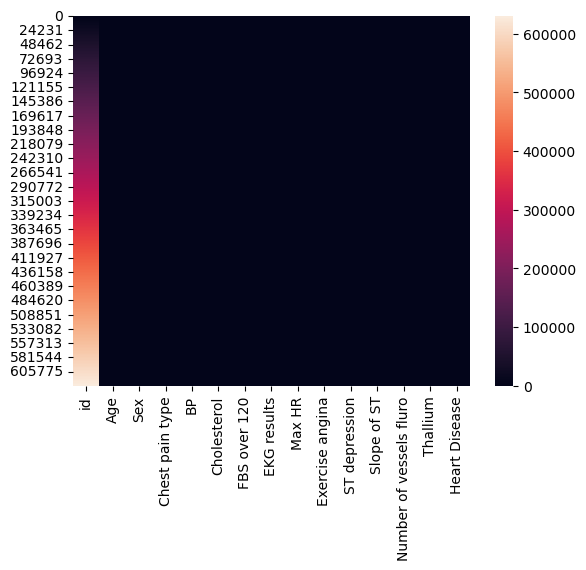

In [95]:
sns.heatmap(df)
plt.show()

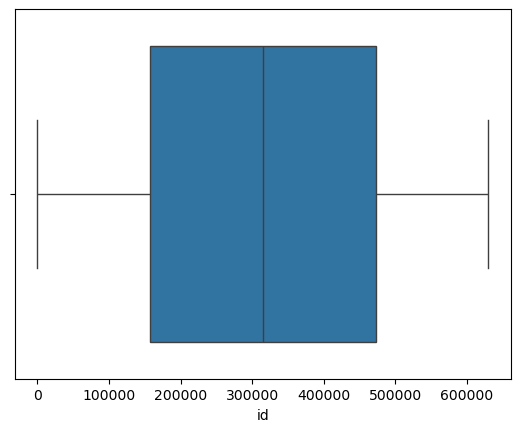

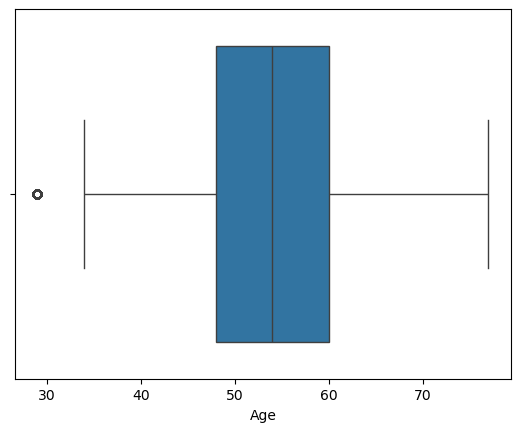

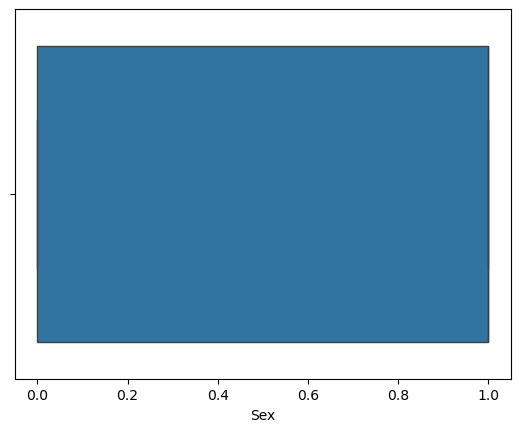

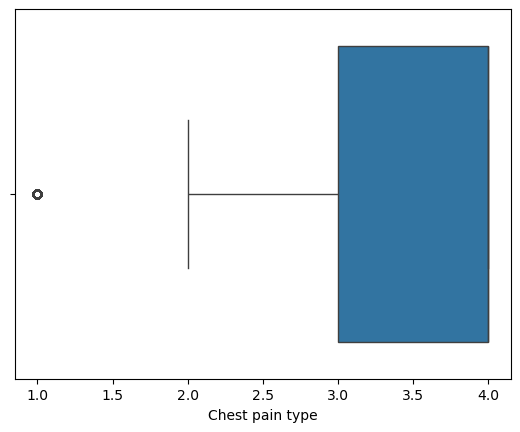

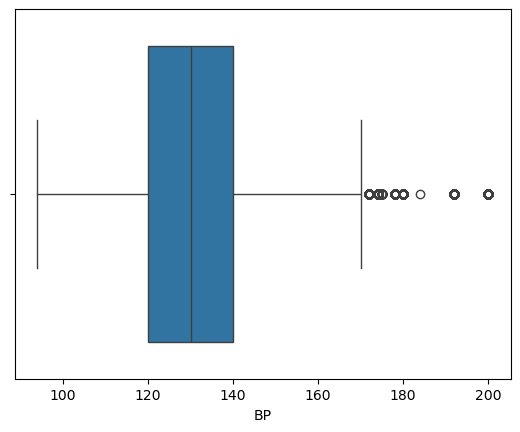

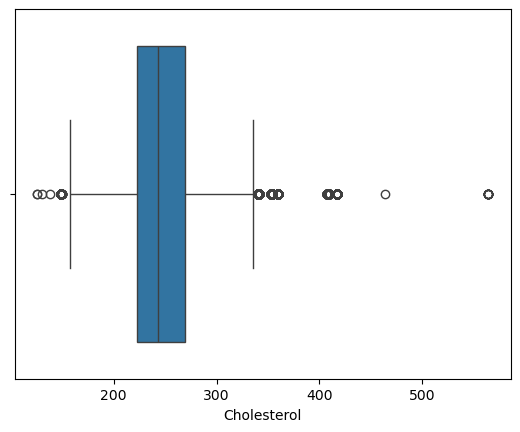

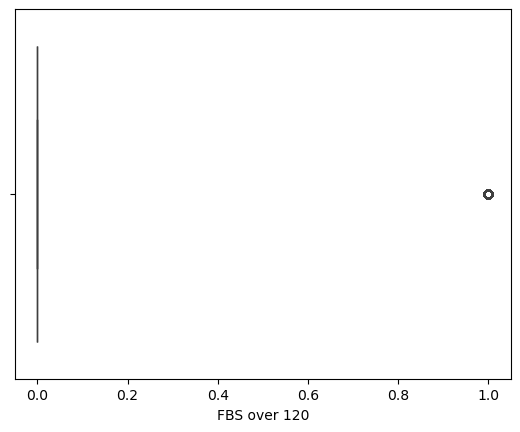

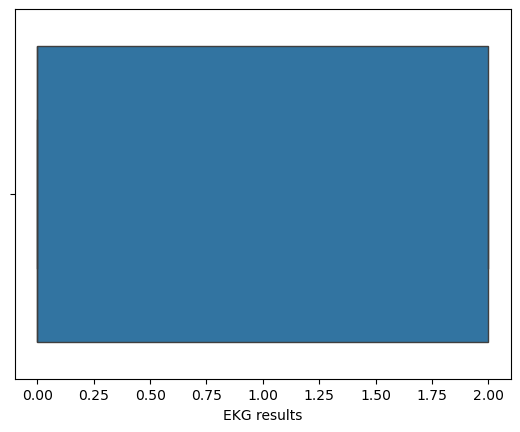

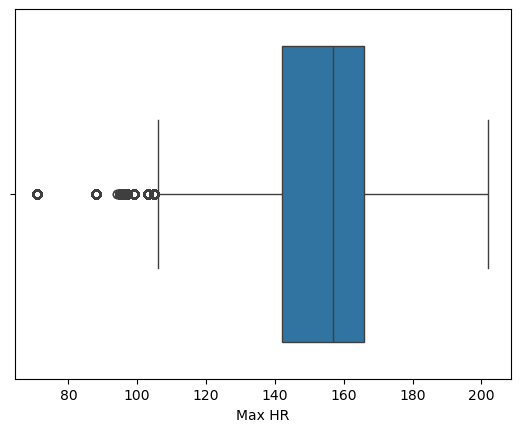

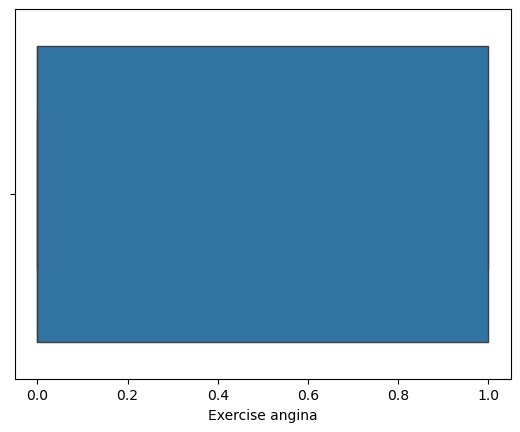

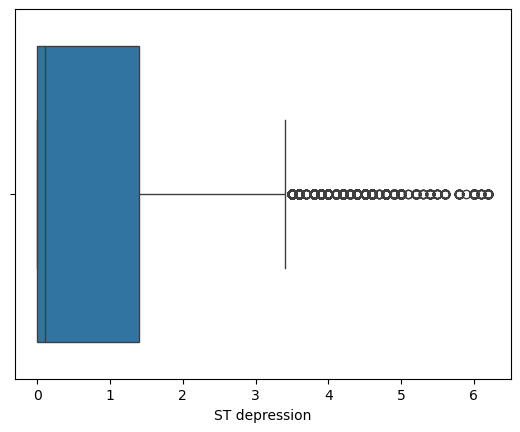

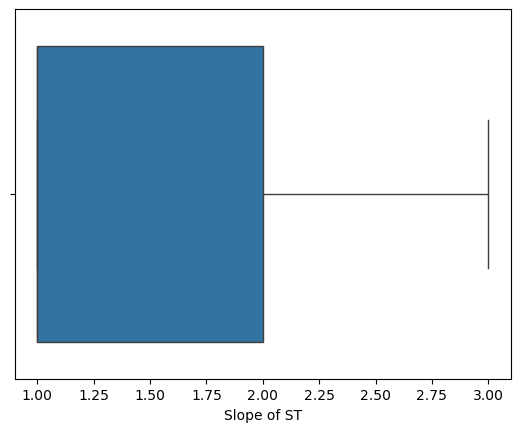

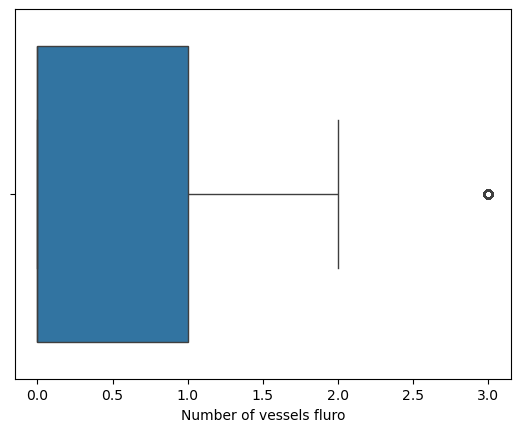

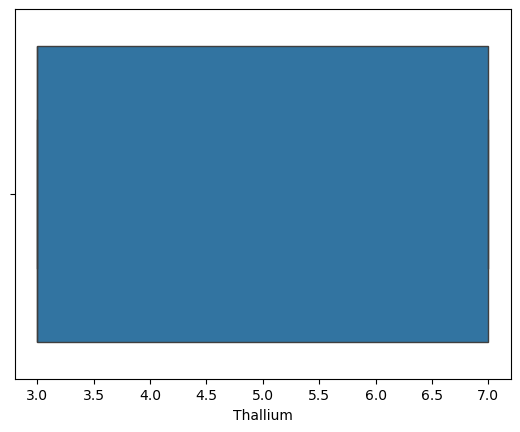

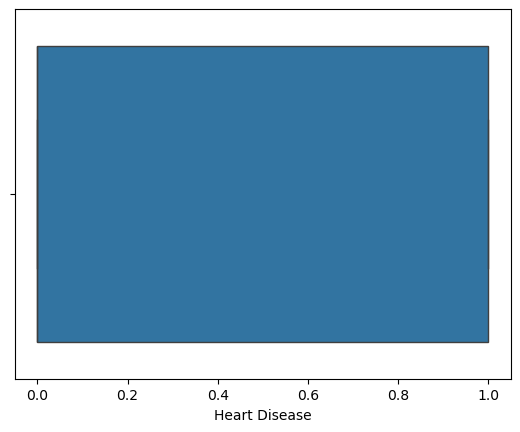

In [97]:
for column in df.columns:
    sns.boxplot(x=df[column])
    plt.show()

In [98]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

std.fit_transform(df)

array([[-1.73204806,  0.46792102,  0.63175953, ...,  1.93972073,
         1.22108704,  1.10925727],
       [-1.73204256, -0.25879726,  0.63175953, ..., -0.56482469,
        -0.83018876, -0.90150412],
       [-1.73203706,  0.22568159, -1.58288074, ..., -0.56482469,
        -0.83018876, -0.90150412],
       ...,
       [ 1.73203706,  1.55799844,  0.63175953, ...,  1.93972073,
         1.22108704,  1.10925727],
       [ 1.73204256, -0.25879726,  0.63175953, ..., -0.56482469,
         0.70826809,  1.10925727],
       [ 1.73204806, -0.37991697, -1.58288074, ..., -0.56482469,
        -0.83018876, -0.90150412]])

In [101]:

df = pd.DataFrame(std.fit_transform(df), columns=df.columns, index=df.index)

In [159]:
df.drop('id',axis=1,inplace=True)

In [161]:
X = df.drop('Heart Disease',axis=1)
y = df['Heart Disease']

In [163]:
X

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7
629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3
629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7
629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6


In [165]:
y

0         1
1         0
2         0
3         0
4         1
         ..
629995    0
629996    0
629997    1
629998    1
629999    0
Name: Heart Disease, Length: 630000, dtype: int64

In [167]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [169]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [171]:
X_train_pred = model.predict(X_train)

In [173]:
X_train_pred

array([1, 0, 1, ..., 1, 1, 0])

In [175]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(X_train_pred,y_train)

In [177]:
acc

0.8813571428571428

In [179]:
X_test_pred = model.predict(X_test)

In [181]:
acc = accuracy_score(X_test_pred,y_test)

In [183]:
acc

0.8806904761904762

In [185]:
data = np.asarray([58,1,4,152,239,0,0,158,1,3.6,2,2,7],dtype=int).reshape(1,-1)

In [187]:
res = model.predict(data)[0]

In [191]:
if res == 0:
    print("You are safe buddy")
else:
    print("This is the end🫠")

This is the end🫠


In [193]:
import pickle

In [195]:
pickle.dump(model,open('model.pkl','wb'))

In [197]:
pickled_model = pickle.load(open('model.pkl','rb'))

In [199]:
pickled_model.predict(data)[0]

1